In [1]:
import torch
import sys
sys.path.append('../')
from app.vjepa.utils import init_opt, init_video_model, load_checkpoint
import yaml
import copy
from torch.nn.parallel import DistributedDataParallel
from src.utils.distributed import init_distributed

/home/manuel/miniconda3/envs/vjepa2/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
sample = torch.load('./EK100-1vid-long-vjepa/sample.pt')

In [3]:
fname = '../configs/train/vitl16-EK100/pretrain-long-vjepa.yaml'
with open(fname, "r") as y_file:
        params = yaml.load(y_file, Loader=yaml.FullLoader)

# Loading the checkpoints

In [4]:
cfgs_model = params.get("model")
use_activation_checkpointing = cfgs_model.get("use_activation_checkpointing", False)
use_rope = cfgs_model.get("use_rope", False)
wide_silu = cfgs_model.get("wide_silu", True)
use_pred_silu = cfgs_model.get("use_pred_silu", False)
use_silu = cfgs_model.get("use_silu", False)
uniform_power = cfgs_model.get("uniform_power", False)
use_mask_tokens = cfgs_model.get("use_mask_tokens", False)
cfgs_mask = params.get("mask")
cfgs_data = params.get("data")
dataset_fpcs = cfgs_data.get("dataset_fpcs")
max_num_frames = max(dataset_fpcs)
zero_init_mask_tokens = cfgs_model.get("zero_init_mask_tokens", True)
patch_size = cfgs_data.get("patch_size")
tubelet_size = cfgs_data.get("tubelet_size")
crop_size = cfgs_data.get("crop_size", 224)
cfgs_meta = params.get("meta")
use_sdpa = cfgs_meta.get("use_sdpa", False)
model_name = cfgs_model.get("model_name")
pred_depth = cfgs_model.get("pred_depth")
pred_num_heads = cfgs_model.get("pred_num_heads", None)
is_causal = cfgs_model.get("is_causal", False)
pred_embed_dim = cfgs_model.get("pred_embed_dim")
device = torch.device("cuda:0")

In [5]:
encoder, predictor = init_video_model(
    uniform_power=uniform_power,
    use_mask_tokens=use_mask_tokens,
    num_mask_tokens=int(len(cfgs_mask) * len(dataset_fpcs)),
    zero_init_mask_tokens=zero_init_mask_tokens,
    device=device,
    patch_size=patch_size,
    max_num_frames=max_num_frames,
    tubelet_size=tubelet_size,
    model_name=model_name,
    crop_size=crop_size,
    pred_depth=pred_depth,
    pred_num_heads=pred_num_heads,
    pred_embed_dim=pred_embed_dim,
    use_sdpa=use_sdpa,
    use_silu=use_silu,
    use_pred_silu=use_pred_silu,
    wide_silu=wide_silu,
    use_rope=use_rope,
    use_activation_checkpointing=use_activation_checkpointing,
    is_causal=is_causal
)
target_encoder = copy.deepcopy(encoder)

[INFO    ][2026-04-17 13:44:32][root                ][init_video_model         ] MultiSeqWrapper(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed3D(
      (proj): Conv3d(3, 1024, kernel_size=(1, 256, 256), stride=(1, 256, 256))
    )
    (blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): RoPEAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout

In [6]:
cfgs_opt = params.get("optimization")
is_anneal = cfgs_opt.get("is_anneal", False)
wd = float(cfgs_opt.get("weight_decay"))
final_wd = float(cfgs_opt.get("final_weight_decay"))
num_epochs = cfgs_opt.get("epochs")
warmup = cfgs_opt.get("warmup")
start_lr = cfgs_opt.get("start_lr")
lr = cfgs_opt.get("lr")
final_lr = cfgs_opt.get("final_lr")
ema = cfgs_opt.get("ema")
betas = cfgs_opt.get("betas", (0.9, 0.999))
eps = cfgs_opt.get("eps", 1.0e-8)
ipe = cfgs_opt.get("ipe", None)
ipe_scale = cfgs_opt.get("ipe_scale", 1.0)
which_dtype = cfgs_meta.get("dtype")
if which_dtype.lower() == "bfloat16":
    dtype = torch.bfloat16
    mixed_precision = True
elif which_dtype.lower() == "float16":
    dtype = torch.float16
    mixed_precision = True
else:
    dtype = torch.float32
    mixed_precision = False

optimizer, scaler, scheduler, wd_scheduler = init_opt(
    is_anneal=is_anneal,
    encoder=encoder,
    predictor=predictor,
    wd=wd,
    final_wd=final_wd,
    start_lr=start_lr,
    ref_lr=lr,
    final_lr=final_lr,
    iterations_per_epoch=ipe,
    warmup=warmup,
    num_epochs=num_epochs,
    ipe_scale=ipe_scale,
    mixed_precision=mixed_precision,
    betas=betas,
    eps=eps,
)

/home/manuel/projects/vjepa2/preliminary_experiments/../app/vjepa/utils.py:269: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


In [7]:
world_size, rank = init_distributed(rank_and_world_size=(0, 1))
encoder = DistributedDataParallel(encoder, static_graph=True)
predictor = DistributedDataParallel(predictor, static_graph=False, find_unused_parameters=True)
target_encoder = DistributedDataParallel(target_encoder)

In [8]:
resume_anneal = cfgs_opt.get("resume_anneal", False)
(
    encoder,
    predictor,
    target_encoder,
    optimizer,
    scaler,
    start_epoch,
) = load_checkpoint(
    r_path='./EK100-1vid-long-vjepa/latest.pt',
    encoder=encoder,
    predictor=predictor,
    target_encoder=target_encoder,
    opt=optimizer,
    scaler=scaler,
    is_anneal=is_anneal and not resume_anneal,
)

[INFO    ][2026-04-17 13:45:08][root                ][load_checkpoint          ] Loading checkpoint from ./EK100-1vid-long-vjepa/latest.pt
[INFO    ][2026-04-17 13:45:16][root                ][load_checkpoint          ] loaded pretrained encoder from epoch 200 with msg: <All keys matched successfully>
[INFO    ][2026-04-17 13:45:16][root                ][load_checkpoint          ] loaded pretrained predictor from epoch 200 with msg: <All keys matched successfully>
['encoder', 'predictor', 'opt', 'scaler', 'target_encoder', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
[INFO    ][2026-04-17 13:45:16][root                ][load_checkpoint          ] loaded pretrained target encoder from epoch 200 with msg: <All keys matched successfully>
[INFO    ][2026-04-17 13:45:17][root                ][load_checkpoint          ] loaded optimizers from epoch 200
[INFO    ][2026-04-17 13:45:17][root                ][load_checkpoint          ] read-path: ./EK100-1vid-long-vjepa/latest.pt


# Analyzing the encoded features

Create a decoder of the features

In [9]:
from torch import nn
decoder = nn.ConvTranspose3d(
    in_channels=1024,
    out_channels=3,
    kernel_size=(tubelet_size, patch_size, patch_size),
    stride=(tubelet_size, patch_size, patch_size),
)
decoder.weight.data = target_encoder.module.backbone.patch_embed.proj.weight.data.cpu()

Compare the decoder precision against the real image

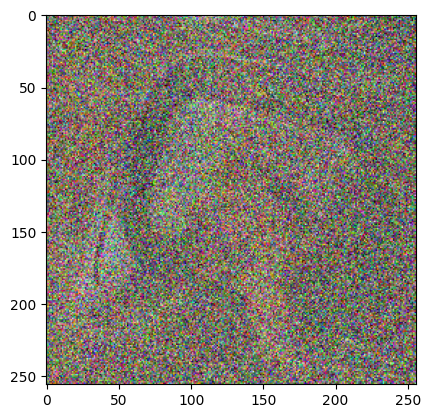

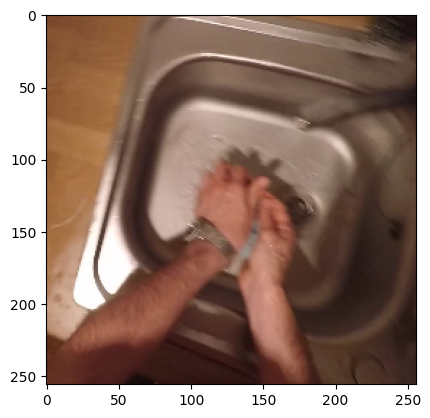

Reconstruction error: 1.03


In [10]:
import matplotlib.pyplot as plt

def decode_features(features):
    with torch.no_grad():
        decoded_video = decoder(features.transpose(1,2).reshape(1, features.size(-1), max_num_frames, 1, 1).cpu())

    return decoded_video

def show_frame(decoded_video, frame_id): # [B,C,T,H,W]
    # unnormalize the features
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    mean, std = torch.tensor(mean)*255, torch.tensor(std)*255
    mean, std = mean.reshape(3,1,1,1), std.reshape(3,1,1,1)
    decoded_video = decoded_video[0]*std + mean # Take the 1st video

    # Show frame
    frame = decoded_video.permute(1,2,3,0)[frame_id]
    plt.imshow(frame.clamp(0, 255).to(torch.int32))
    plt.show()
    

# Patchify the original sample
batch = [s.to(device) for s in sample]
with torch.no_grad():
    original_patches = target_encoder.module.backbone.patch_embed(batch[0])


def reconstruction_error(decoded_vid1, decoded_vid2): # [B,C,T,H,W]
    decoded_vid1 = decoded_vid1.permute(0,2,3,4,1) # [B,T,H,W,C]
    decoded_vid2 = decoded_vid2.permute(0,2,3,4,1)
    diff = torch.abs(decoded_vid1 - decoded_vid2)
    return diff.mean([1,2,3,4]).mean() # average over frames and then over the batch

# Show original image patchify and then decoded
org_patches_decoded = decode_features(original_patches)

# normalized batch: The features are normalized over the emb dim
# So it's better to normalized the patches values
org_patches_decoded = torch.nn.functional.layer_norm(org_patches_decoded, (org_patches_decoded.size(-1),))

frame_id = 5
show_frame(org_patches_decoded, frame_id)
# Show original image
show_frame(batch[0].cpu(), frame_id)
print(f'Reconstruction error: {reconstruction_error(org_patches_decoded,batch[0].cpu()):,.2f}')

The decoder is not very accurate since it is just a transposed convolution, and a lot of information has already being lost is the patchify operation. Some of this information is not recoverable.

## Analyzing the target encoder features

/home/manuel/miniconda3/envs/vjepa2/lib/python3.14/contextlib.py:109: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


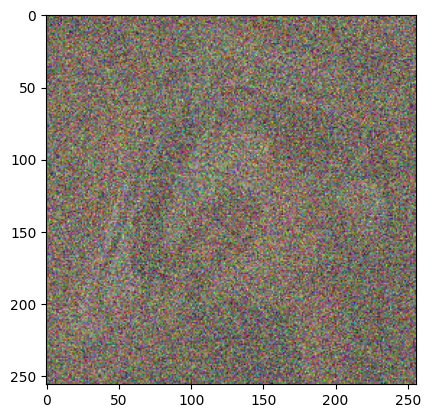

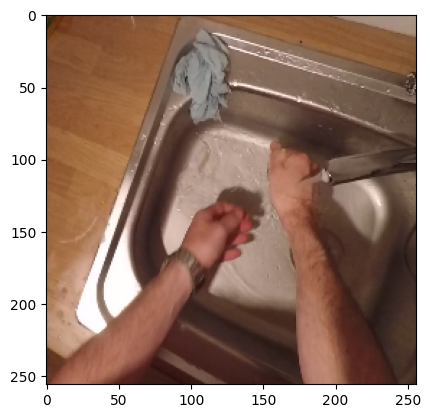

Reconstruction error: 0.84


In [11]:
with torch.no_grad():
    target_encoder_features = target_encoder(batch)
target_encoder_features = target_encoder_features[0].cpu()

# decode the features
decoded = decode_features(target_encoder_features)

frame_id = 0
# Show decoded features
show_frame(decoded, frame_id)
# Show original image
show_frame(batch[0].cpu(), frame_id)
print(f'Reconstruction error: {reconstruction_error(decoded,batch[0].cpu()):,.2f}')

We can see that the target encoder features preserve some information about the image that looks similar to the information preserved by the 3d convolution layer.

Similarity of the raw 3d convolution output and the final encoder output in embedding space

In [14]:
torch.abs(torch.nn.functional.layer_norm(target_encoder_features, (1024,)) - torch.nn.functional.layer_norm(original_patches.cpu(), (1024,))).mean(dim=-1).mean()

tensor(0.0692)

We observe that after normalization the output of the encoder is actually pretty close to the patchification output. This implies that the encoder is not changing much the data, and it's letting the hard work to the predictor.

## Analyzing the predictor output

input features of the predictor


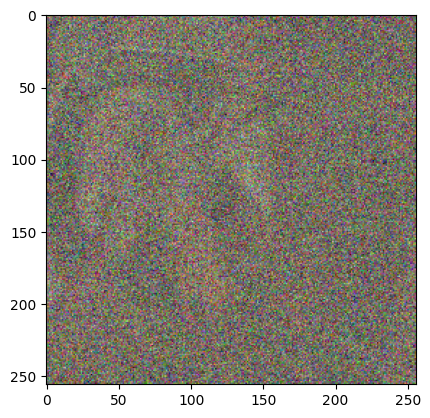

output features of the predictor


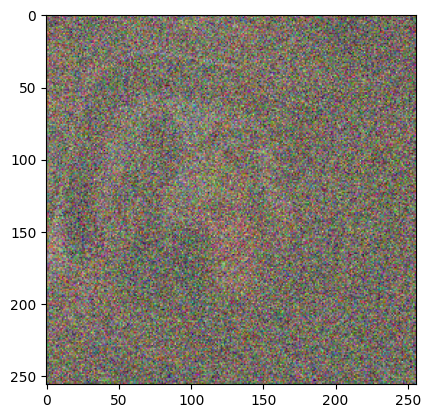

patchified original next image


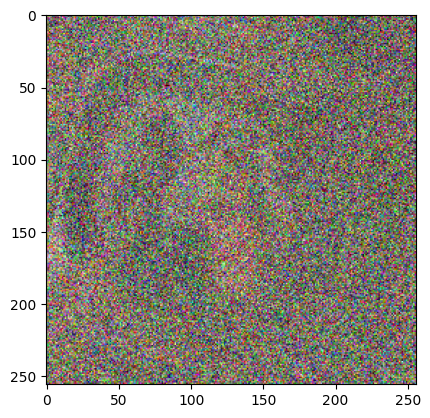

Reconstruction error against the patchified real images (emb space): 0.07
Reconstruction error against the encoded real images (loss objective) (emb space): 0.0259


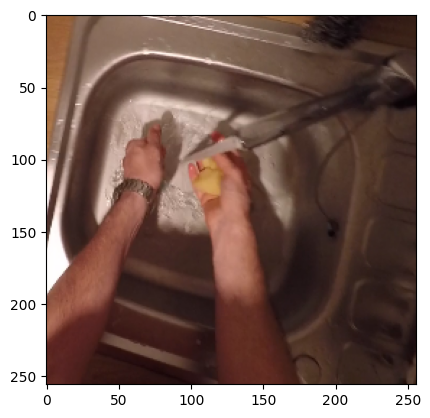

Reconstruction error (pixel space): 0.84


In [23]:
with torch.no_grad():
    context_encoder_features = encoder(batch)
    predicted_features = predictor(context_encoder_features, is_causal=True)
    target_encoder_features = target_encoder(batch)
    

target_encoder_features = target_encoder_features[0].cpu()
predicted_features = predicted_features[0].cpu()

# decode the features
predicted_decoded = decode_features(predicted_features)

target_encoder_features = torch.nn.functional.layer_norm(target_encoder_features,(1024,))[:,1:]
predicted_features = predicted_features[:,:-1]

frame_id = 2
# Show input features of the predictor
print('input features of the predictor')
show_frame(decoded, frame_id)
# Show output features of the predictor
print('output features of the predictor')
show_frame(predicted_decoded, frame_id)
# Show the patchified original next image
print('patchified original next image')
show_frame(org_patches_decoded, frame_id + 1)
print(f'Reconstruction error against the patchified real images (emb space): {torch.abs(predicted_features-torch.nn.functional.layer_norm(original_patches[:,1:].cpu(),(1024,))).mean():,.2f}')
print(f'Reconstruction error against the encoded real images (loss objective) (emb space): {torch.abs(predicted_features-target_encoder_features).mean():,.4f}')

# Show the next original image
show_frame(batch[0].cpu(), frame_id+1)
print(f'Reconstruction error (pixel space): {reconstruction_error(predicted_decoded[:,:,:-1],batch[0].cpu()[:,:,1:]):,.2f}')

The predictor is most probably memorizing how to pass from one state to the other. We can see that the loss objective used for training would we pretty close to the loss observed at training time.